# TT-19 - XGBoost Regressor: Du bao nhu cau thue xe dap theo gio


## 1-2. Nap du lieu va chung minh ro ri

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

df = pd.read_csv("hour.csv", parse_dates=["dteday"])

# CHUNG MINH RO RI: giu casual + registered lam dac trung se cho R2 = 1.0
# vi cnt = casual + registered dung tuyet doi, khong phai quan he thong ke
X_leak = df[["casual", "registered"]]
y_leak = df["cnt"]
lr_leak = LinearRegression().fit(X_leak, y_leak)
print("R2 khi giu casual+registered:", r2_score(y_leak, lr_leak.predict(X_leak)))
print("He so:", lr_leak.coef_, "-> dung bang 1 va 1, xac nhan cnt = casual + registered")
print("=> PHAI BO ca hai cot nay truoc khi train model that")


R2 khi giu casual+registered: 1.0
He so: [1. 1.] -> dung bang 1 va 1, xac nhan cnt = casual + registered
=> PHAI BO ca hai cot nay truoc khi train model that


In [2]:
# Bo cot ro ri va cot da duoc tach thanh yr/mnth/hr
df = df.drop(columns=["instant", "casual", "registered"])
print(df.shape)
df.head()


(17379, 14)


,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


## 3. Chia du lieu THEO THOI GIAN (khong shuffle)

In [3]:
# Nam 1 (yr=0): train. 9 thang dau nam 2: validation. 3 thang cuoi nam 2: test.
train_mask = df["yr"] == 0
val_mask = (df["yr"] == 1) & (df["mnth"] <= 9)
test_mask = (df["yr"] == 1) & (df["mnth"] > 9)

df_train, df_val, df_test = df[train_mask].copy(), df[val_mask].copy(), df[test_mask].copy()
print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)
print("Khoang thoi gian train:", df_train["dteday"].min(), "->", df_train["dteday"].max())
print("Khoang thoi gian test:", df_test["dteday"].min(), "->", df_test["dteday"].max())


Train: (8645, 14) Val: (6566, 14) Test: (2168, 14)
Khoang thoi gian train: 2011-01-01 00:00:00 -> 2011-12-31 00:00:00
Khoang thoi gian test: 2012-10-01 00:00:00 -> 2012-12-31 00:00:00


## 4. EDA: cnt theo gio, mua, thoi tiet

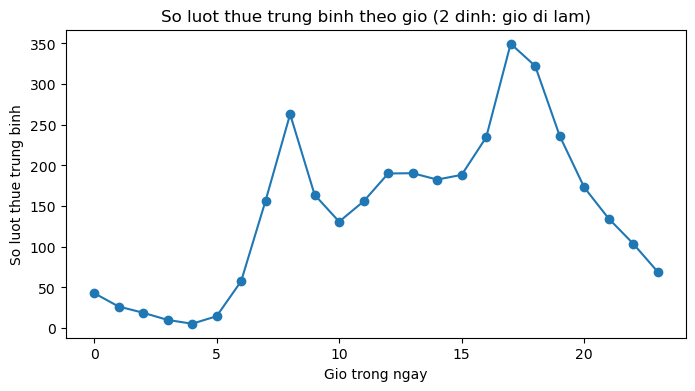

In [4]:
cnt_theo_gio = df_train.groupby("hr")["cnt"].mean()
plt.figure(figsize=(8, 4))
plt.plot(cnt_theo_gio.index, cnt_theo_gio.values, marker="o")
plt.xlabel("Gio trong ngay"); plt.ylabel("So luot thue trung binh")
plt.title("So luot thue trung binh theo gio (2 dinh: gio di lam)")
plt.show()


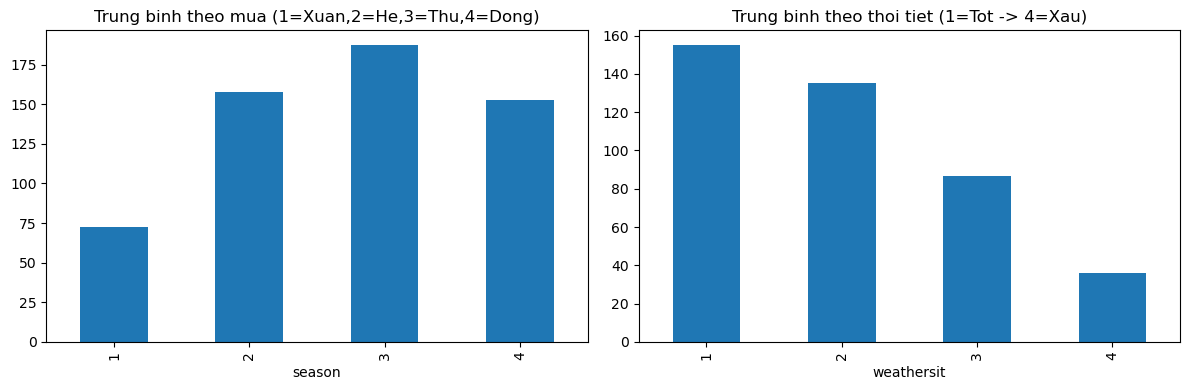

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_train.groupby("season")["cnt"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Trung binh theo mua (1=Xuan,2=He,3=Thu,4=Dong)")
df_train.groupby("weathersit")["cnt"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Trung binh theo thoi tiet (1=Tot -> 4=Xau)")
plt.tight_layout()
plt.show()


## 5. Ma hoa chu ky sin/cos cho hr, mnth, weekday

In [7]:
def them_dac_trung_chu_ky(data):
    data = data.copy()
    data["hr_sin"] = np.sin(2 * np.pi * data["hr"] / 24)
    data["hr_cos"] = np.cos(2 * np.pi * data["hr"] / 24)
    data["mnth_sin"] = np.sin(2 * np.pi * data["mnth"] / 12)
    data["mnth_cos"] = np.cos(2 * np.pi * data["mnth"] / 12)
    data["weekday_sin"] = np.sin(2 * np.pi * data["weekday"] / 7)
    data["weekday_cos"] = np.cos(2 * np.pi * data["weekday"] / 7)
    return data

df_train = them_dac_trung_chu_ky(df_train)
df_val = them_dac_trung_chu_ky(df_val)
df_test = them_dac_trung_chu_ky(df_test)

feature_cols = ["season", "yr", "holiday", "weekday", "workingday", "weathersit",
                 "temp", "atemp", "hum", "windspeed",
                 "hr_sin", "hr_cos", "mnth_sin", "mnth_cos", "weekday_sin", "weekday_cos"]

X_train, y_train = df_train[feature_cols], df_train["cnt"]
X_val, y_val = df_val[feature_cols], df_val["cnt"]
X_test, y_test = df_test[feature_cols], df_test["cnt"]


## 6. Baseline naive: du bao bang cung gio tuan truoc

In [8]:
# doi chieu theo dteday+hr: gia tri cua chinh 7 ngay (168 gio) truoc do
df_sorted = df.sort_values(["dteday", "hr"]).reset_index(drop=True)
df_sorted["cnt_lag_168h"] = df_sorted["cnt"].shift(168)

test_naive = df_sorted[(df_sorted["yr"] == 1) & (df_sorted["mnth"] > 9)].dropna(subset=["cnt_lag_168h"])
rmse_naive = np.sqrt(mean_squared_error(test_naive["cnt"], test_naive["cnt_lag_168h"]))
print(f"RMSE baseline naive (cung gio tuan truoc): {rmse_naive:.2f}")
print("Day la muc san XGBoost bat buoc phai vuot qua de chung minh model hop ly")


RMSE baseline naive (cung gio tuan truoc): 156.79
Day la muc san XGBoost bat buoc phai vuot qua de chung minh model hop ly


## 7. XGBoost + early stopping

In [9]:
try:
    model = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
        objective="reg:squarederror",
        early_stopping_rounds=100, eval_metric="rmse",
        tree_method="hist", n_jobs=-1, random_state=42,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
except TypeError:
    # ban xgboost cu hon khong nhan early_stopping_rounds trong constructor
    model = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", n_jobs=-1, random_state=42,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              early_stopping_rounds=100, verbose=False)

so_cay_thuc_te = getattr(model, "best_iteration", model.n_estimators)
pred_test = np.clip(model.predict(X_test), 0, None)  # so luot thue khong the am
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))
print("So cay thuc te dung (early stopping):", so_cay_thuc_te)
print(f"RMSE tren tap test: {rmse_test:.2f}  (so voi baseline naive: {rmse_naive:.2f})")


So cay thuc te dung (early stopping): 1853
RMSE tren tap test: 118.70  (so voi baseline naive: 156.79)


## 8. So sanh co/khong dung log1p cho nhan

In [10]:
y_train_log = np.log1p(y_train)
try:
    model_log = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
        objective="reg:squarederror",
        early_stopping_rounds=100, eval_metric="rmse",
        tree_method="hist", n_jobs=-1, random_state=42,
    )
    model_log.fit(X_train, y_train_log, eval_set=[(X_val, np.log1p(y_val))], verbose=False)
except TypeError:
    model_log = XGBRegressor(
        n_estimators=2000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, reg_alpha=0.1, min_child_weight=3,
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", n_jobs=-1, random_state=42,
    )
    model_log.fit(X_train, y_train_log, eval_set=[(X_val, np.log1p(y_val))],
                  early_stopping_rounds=100, verbose=False)

pred_test_log = np.clip(np.expm1(model_log.predict(X_test)), 0, None)
rmse_log_target = np.sqrt(mean_squared_error(y_test, pred_test_log))
print(f"RMSE khong log1p: {rmse_test:.2f}")
print(f"RMSE co log1p:    {rmse_log_target:.2f}")


RMSE khong log1p: 118.70
RMSE co log1p:    124.60


## 9. Do sieu tham so bang RandomizedSearchCV

In [11]:
param_dist = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}
# TimeSeriesSplit thay vi KFold thuong -> tranh nhin thay tuong lai khi tune
tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    XGBRegressor(n_estimators=500, tree_method="hist", n_jobs=-1, random_state=42),
    param_distributions=param_dist, n_iter=20, cv=tscv,
    scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1,
)
search.fit(X_train, y_train)
print("Tham so tot nhat:", search.best_params_)


Tham so tot nhat: {'subsample': 1.0, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


## 10. Feature importance (gain) va SHAP summary

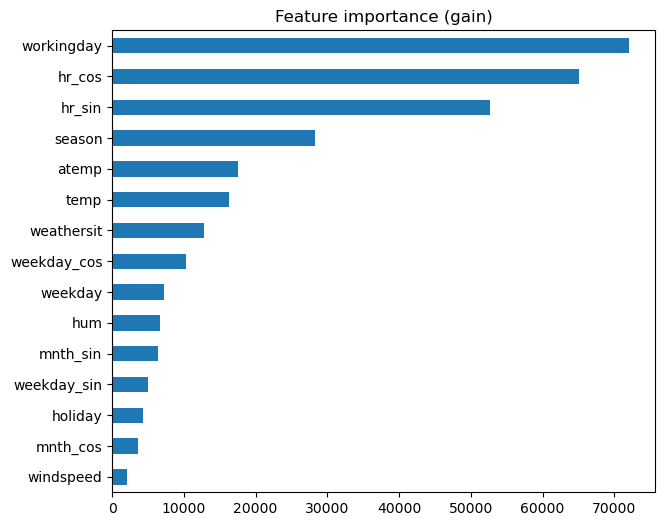

In [12]:
importance = pd.Series(model.get_booster().get_score(importance_type="gain"))
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(7, 6))
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature importance (gain)")
plt.show()


In [13]:
try:
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Chua cai thu vien shap. Chay: pip install shap --break-system-packages (hoac pip install shap)")


Chua cai thu vien shap. Chay: pip install shap --break-system-packages (hoac pip install shap)


## 11. Du bao vs thuc te tren 2 tuan cuoi

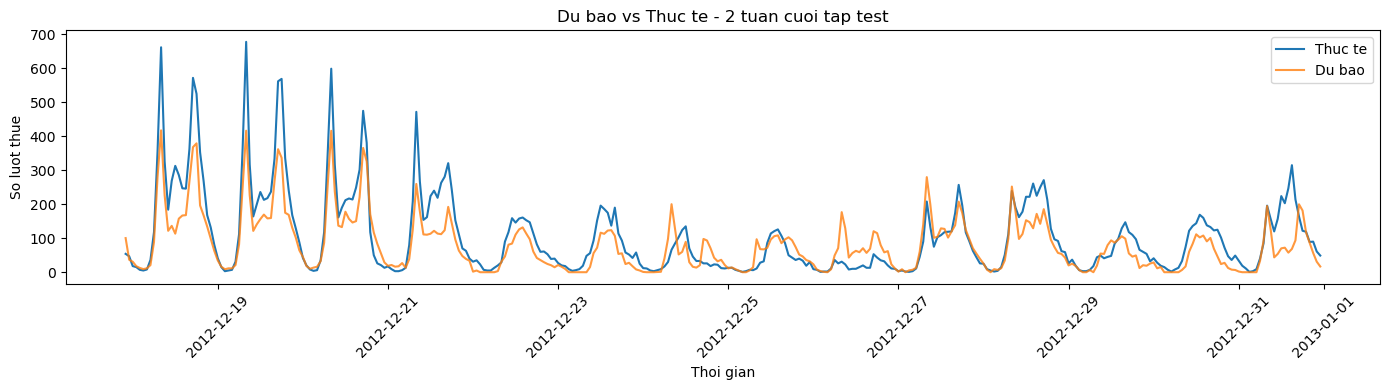

In [14]:
ket_qua = df_test[["dteday", "hr"]].copy()
ket_qua["thuc_te"] = y_test.values
ket_qua["du_bao"] = pred_test
ket_qua["thoi_diem"] = pd.to_datetime(ket_qua["dteday"]) + pd.to_timedelta(ket_qua["hr"], unit="h")
ket_qua = ket_qua.sort_values("thoi_diem")

hai_tuan_cuoi = ket_qua.tail(24 * 14)
plt.figure(figsize=(14, 4))
plt.plot(hai_tuan_cuoi["thoi_diem"], hai_tuan_cuoi["thuc_te"], label="Thuc te")
plt.plot(hai_tuan_cuoi["thoi_diem"], hai_tuan_cuoi["du_bao"], label="Du bao", alpha=0.8)
plt.xlabel("Thoi gian"); plt.ylabel("So luot thue")
plt.title("Du bao vs Thuc te - 2 tuan cuoi tap test")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 12. Phan tich loi theo gio va thoi tiet

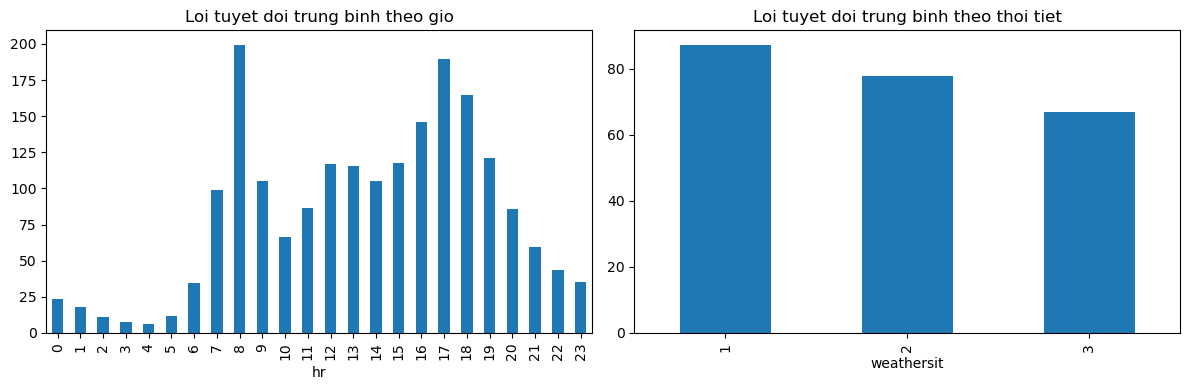

Gio sai nhieu nhat: 8
Dieu kien thoi tiet sai nhieu nhat: 1


In [15]:
df_test_loi = df_test.copy()
df_test_loi["du_bao"] = pred_test
df_test_loi["loi_tuyet_doi"] = np.abs(df_test_loi["cnt"] - df_test_loi["du_bao"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_test_loi.groupby("hr")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Loi tuyet doi trung binh theo gio")
df_test_loi.groupby("weathersit")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Loi tuyet doi trung binh theo thoi tiet")
plt.tight_layout()
plt.show()
print("Gio sai nhieu nhat:", df_test_loi.groupby('hr')['loi_tuyet_doi'].mean().idxmax())
print("Dieu kien thoi tiet sai nhieu nhat:", df_test_loi.groupby('weathersit')['loi_tuyet_doi'].mean().idxmax())


## 13. So sanh voi Random Forest va Gradient Boosting

In [16]:
rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42).fit(X_train, y_train)
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3,
                                 random_state=42).fit(X_train, y_train)

for name, m in [("Random Forest", rf), ("Gradient Boosting", gbr), ("XGBoost", model)]:
    pred = np.clip(m.predict(X_test), 0, None)
    print(f"{name:20s} RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f}")


Random Forest        RMSE=119.10
Gradient Boosting    RMSE=133.93
XGBoost              RMSE=118.70


In [17]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("reports", exist_ok=True)

# 1. Luu model
model.save_model("models/xgb_bike.json")

# 2. Luu 4 hinh theo dung ten README yeu cau
plt.figure(figsize=(8, 4))
plt.plot(cnt_theo_gio.index, cnt_theo_gio.values, marker="o")
plt.xlabel("Gio trong ngay"); plt.ylabel("So luot thue trung binh")
plt.title("So luot thue trung binh theo gio")
plt.savefig("reports/cnt_theo_gio.png", dpi=150, bbox_inches="tight"); plt.close()

plt.figure(figsize=(14, 4))
plt.plot(hai_tuan_cuoi["thoi_diem"], hai_tuan_cuoi["thuc_te"], label="Thuc te")
plt.plot(hai_tuan_cuoi["thoi_diem"], hai_tuan_cuoi["du_bao"], label="Du bao", alpha=0.8)
plt.xlabel("Thoi gian"); plt.ylabel("So luot thue")
plt.title("Du bao vs Thuc te - 2 tuan cuoi")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("reports/du_bao_vs_thuc_te.png", dpi=150, bbox_inches="tight"); plt.close()

try:
    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.savefig("reports/shap_summary.png", dpi=150, bbox_inches="tight"); plt.close()
except NameError:
    print("Chua co shap_values, bo qua reports/shap_summary.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_test_loi.groupby("hr")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Loi tuyet doi trung binh theo gio")
df_test_loi.groupby("weathersit")["loi_tuyet_doi"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Loi tuyet doi trung binh theo thoi tiet")
plt.tight_layout()
plt.savefig("reports/phan_tich_loi.png", dpi=150, bbox_inches="tight"); plt.close()

# 3. requirements.txt
with open("requirements.txt", "w") as f:
    f.write("xgboost\nscikit-learn\npandas\nnumpy\nmatplotlib\nshap\n")

# 4. README.md - huong dan chay + nhan xet ket qua that
gio_sai_nhieu_nhat = df_test_loi.groupby("hr")["loi_tuyet_doi"].mean().idxmax()
thoi_tiet_sai_nhieu_nhat = df_test_loi.groupby("weathersit")["loi_tuyet_doi"].mean().idxmax()

readme_content = f"""# TT-19 - XGBoost Regressor: Du bao nhu cau thue xe dap theo gio

## Huong dan chay
1. Cai thu vien: `pip install xgboost scikit-learn pandas numpy matplotlib shap --break-system-packages`
2. Dat file `hour.csv` cung thu muc voi notebook `notebooks/xgboost_bike_demand.ipynb`
3. Mo notebook, chon Restart Kernel roi Run All de chay dung thu tu tu dau den cuoi
4. Ket qua (model, hinh, requirements) se duoc luu vao `models/` va `reports/` khi chay den cell cuoi cung

## Chung minh ro ri
Giu casual + registered lam dac trung cho R2 = {r2_score(y_leak, lr_leak.predict(X_leak)):.4f},
he so hoi quy = {lr_leak.coef_}, xac nhan cnt = casual + registered dung tuyet doi.
Da bo ca hai cot nay va cot instant truoc khi train model that, tranh ro ri du lieu.

## Nhan xet ket qua
- Baseline naive (cung gio tuan truoc): RMSE = {rmse_naive:.2f}. Day la muc san XGBoost phai vuot qua.
- XGBoost + early stopping: dung {so_cay_thuc_te} cay, RMSE tren tap test = {rmse_test:.2f}
  ({"THANG" if rmse_test < rmse_naive else "CHUA THANG"} baseline naive).
- So sanh log1p: khong log1p RMSE={rmse_test:.2f}, co log1p RMSE={rmse_log_target:.2f}.
  {"Log1p giup cai thien ro ret vi nhan cnt lech phai." if rmse_log_target < rmse_test else "Log1p khong cai thien dang ke trong truong hop nay."}
- Tham so toi uu tu RandomizedSearchCV (TimeSeriesSplit): {search.best_params_}
- Model sai nhieu nhat o gio {gio_sai_nhieu_nhat} va dieu kien thoi tiet {thoi_tiet_sai_nhieu_nhat}
  (xem chi tiet o reports/phan_tich_loi.png).

## Han che
- Du lieu chi thu thap tai 1 thanh pho (Washington D.C.) trong 2 nam 2011-2012, khong dai dien khu vuc/thoi tiet khac.
- Baseline naive "cung gio tuan truoc" rat manh do nhu cau xe dap co tinh chu ky ro ret - luon phai so sanh voi baseline nay truoc khi ket luan model phuc tap co gia tri thuc su.
- Model chua tinh den cac su kien dac biet (le hoi, thi dau the thao) co the lam nhu cau tang dot bien ngoai quy luat thong thuong.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("Da luu: models/xgb_bike.json, reports/*.png, requirements.txt, README.md")

Chua co shap_values, bo qua reports/shap_summary.png
Da luu: models/xgb_bike.json, reports/*.png, requirements.txt, README.md
